# dPCA example

In [18]:
from numpy import *
import matplotlib.pyplot as plt
from dPCA import dPCA
from mpl_toolkits.mplot3d import Axes3D
from numpy.random import rand, randn, randint
# Configure plotting style
plt.style.use('ggplot')
%matplotlib inline

In [19]:
# number of neurons, time-points and stimuli
N,T,S = 100,250,6

# noise-level and number of trials in each condition
noise, n_samples = 0.2, 10

# build two latent factors
zt = (arange(T)/float(T))
zs = (arange(S)/float(S))

# build trial-by trial data
trialR = noise*randn(n_samples,N,S,T)
trialR += randn(N)[None,:,None,None]*zt[None,None,None,:]
trialR += randn(N)[None,:,None,None]*zs[None,None,:,None]

# trial-average data
R = mean(trialR,0)

# center data
R -= mean(R.reshape((N,-1)),1)[:,None,None]

We then instantiate a dPCA model where the two parameter axis are labeled by 's' (stimulus) and 't' (time) respectively. We set regularizer to 'auto' to optimize the regularization parameter when we fit the data.

In [20]:
dpca = dPCA.dPCA(labels='st',regularizer='auto')
dpca.protect = ['t']

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.


Now fit the data (R) using the model we just instatiated. Note that we only need trial-to-trial data when we want to optimize over the regularization parameter.

In [21]:
Z = dpca.fit_transform(R,trialR)

Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0003214199700417736
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.


In [23]:
#lets see Z dimentions
print(Z.keys())

dict_keys(['s', 't', 'st'])


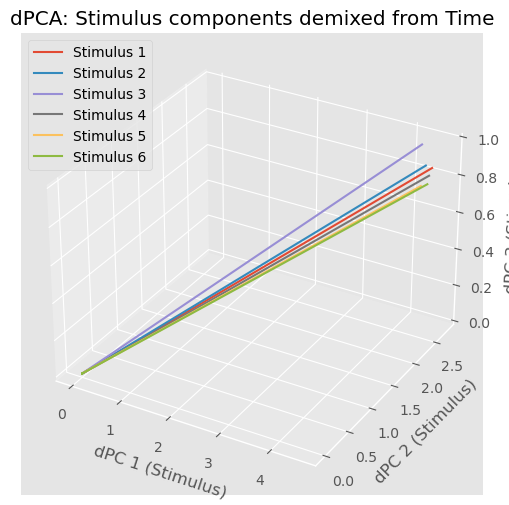

In [24]:
#lets plot the trajectories up until 5 time steps after the first stim,with one axes being the first time component and the second axis being the first stim component
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

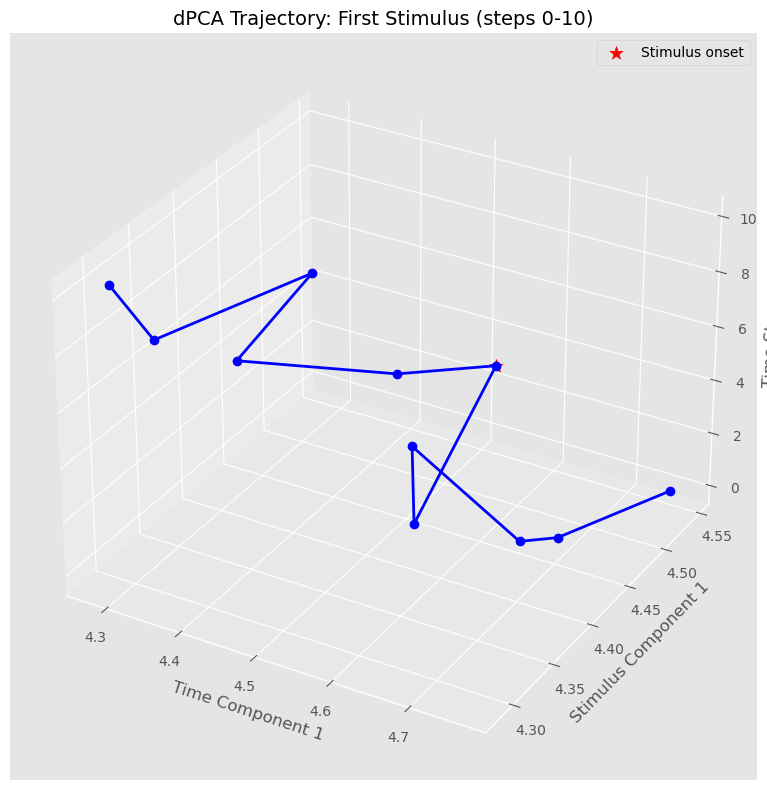

In [28]:
# Plot trajectory for first stimulus: 5 steps before, stim, and 5 steps after
# Using first time component (Z['t'][0]) and first stim component (Z['s'][0])

# Define the window: pick a stim time that allows 5 steps before
before_steps = 5
after_steps = 5
stim_time = before_steps  # This ensures we can show 5 steps before
start_time = stim_time - before_steps
end_time = stim_time + after_steps + 1

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory for first stimulus (s=0) only
s = 0
time_component = Z['t'][0, s, start_time:end_time]
stim_component = Z['s'][0, s, start_time:end_time]
time_index = arange(start_time, end_time)

ax.plot(time_component, stim_component, time_index, 
        linewidth=2, marker='o', markersize=6, color='blue')

# Highlight the stimulus time point
stim_idx = before_steps  # Index within our extracted window
ax.scatter(time_component[stim_idx], 
          stim_component[stim_idx], 
          time_index[stim_idx],
          color='red', s=100, marker='*', label='Stimulus onset', zorder=5)

ax.set_xlabel('Time Component 1', fontsize=12)
ax.set_ylabel('Stimulus Component 1', fontsize=12)
ax.set_zlabel('Time Step', fontsize=12)
ax.set_title(f'dPCA Trajectory: First Stimulus (steps {start_time}-{end_time-1})', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


In [29]:
# Standard PCA for comparison
from sklearn.decomposition import PCA

# Reshape data for standard PCA: (N neurons, S*T samples)
R_reshaped = R.reshape(N, -1).T  # (S*T, N)

# Fit PCA
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(R_reshaped)  # (S*T, 2)

# Reshape back to (2 components, S stimuli, T time)
Z_pca_reshaped = Z_pca.T.reshape(2, S, T)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PCA explained variance ratio: [0.54349645 0.43365531]
Total variance explained: 97.72%


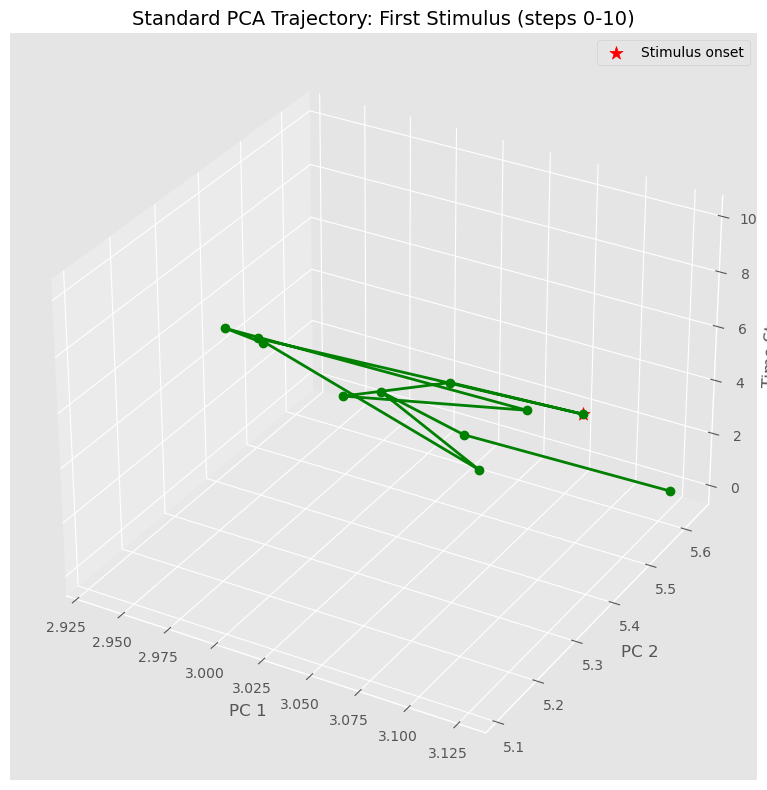

In [30]:
# Plot PCA trajectory: 5 steps before, stim, and 5 steps after
before_steps = 5
after_steps = 5
stim_time = before_steps
start_time = stim_time - before_steps
end_time = stim_time + after_steps + 1

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory for first stimulus (s=0) only
s = 0
pc1 = Z_pca_reshaped[0, s, start_time:end_time]
pc2 = Z_pca_reshaped[1, s, start_time:end_time]
time_index = arange(start_time, end_time)

ax.plot(pc1, pc2, time_index, 
        linewidth=2, marker='o', markersize=6, color='green')

# Highlight the stimulus time point
stim_idx = before_steps
ax.scatter(pc1[stim_idx], 
          pc2[stim_idx], 
          time_index[stim_idx],
          color='red', s=100, marker='*', label='Stimulus onset', zorder=5)

ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_zlabel('Time Step', fontsize=12)
ax.set_title(f'Standard PCA Trajectory: First Stimulus (steps {start_time}-{end_time-1})', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

# simulate a recurring network

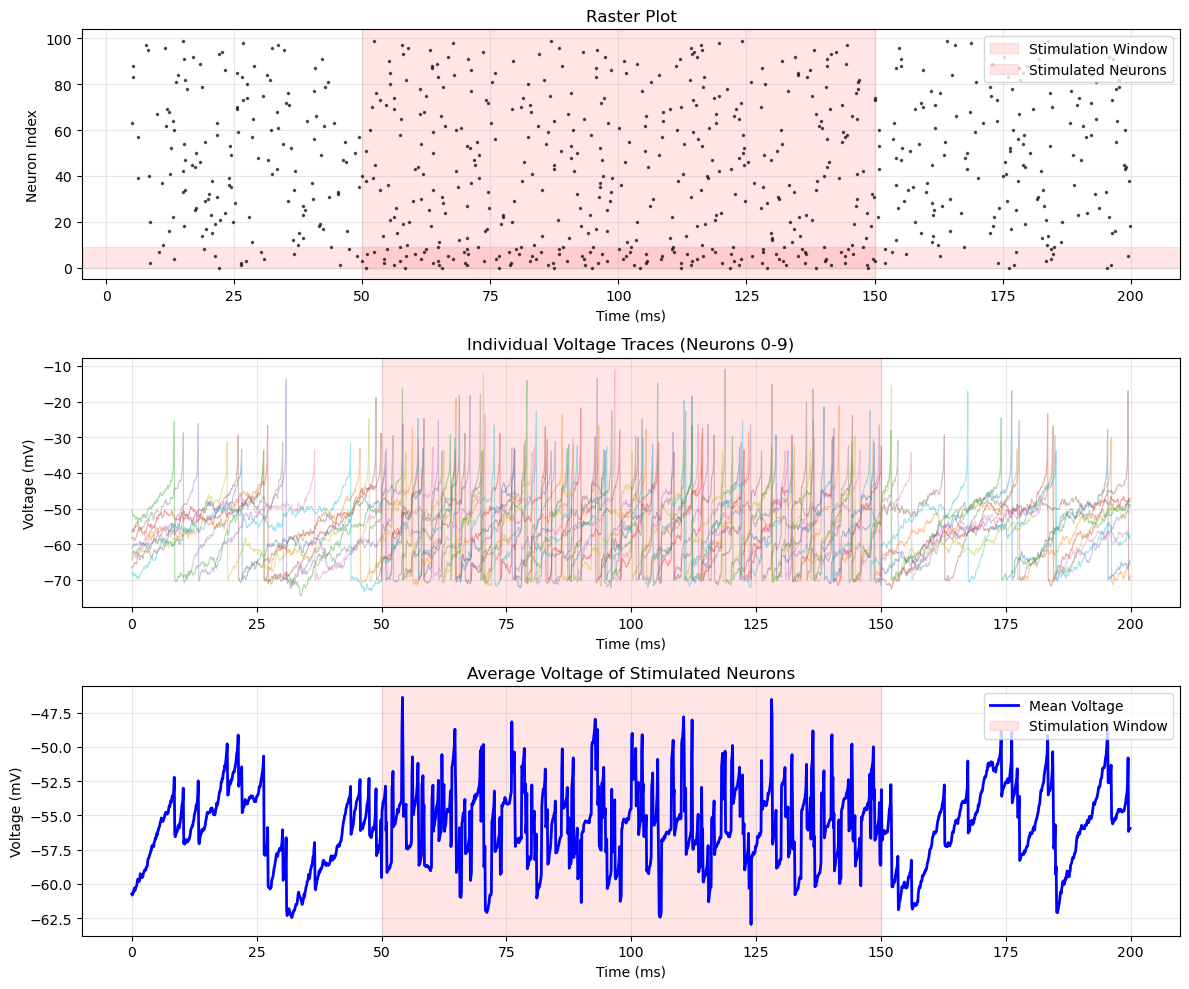

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import brian2 as b2
from brian2 import ms, mV, pA, nA, Hz

b2.start_scope()

# --- 1. Neuron Group Setup ---
n = 100
ng = b2.NeuronGroup(
    n,
    '''
    dv/dt = (
    -(v - E_L) 
    + Delta_T*exp((v-theta)/Delta_T) 
    + Rm*(I_exc + I_bg)
    ) / tau_m + sigma*sqrt(2/tau_m)*xi: volt
    I_exc : amp 
    ''',
    threshold="v > -10*mV",
    reset="v=E_L",
    namespace={
        "tau_m": 20 * ms,
        "Rm": 500 * b2.Mohm,
        "theta": -50 * mV,
        "Delta_T": 2 * mV,
        "E_L": -70 * mV,
        "sigma": 5 * mV,
        "I_bg": 60 * pA,
    },
    method='euler'
)
ng.v = np.random.uniform(-70, -50, n) * mV
ng.I_exc = 0 * pA

# --- 2. Recurrent Connectivity ---
W = 1 * mV
n_neighbors = 40
S_ee = b2.Synapses(ng, model="w: 1", on_pre="v_post+=W*w/sqrt(n)")
S_ee.connect(condition="abs(i-j)<=n_neighbors and i!=j")

number_of_synapses = len(S_ee)
S_ee.w = np.exp(np.random.randn(number_of_synapses)) * np.random.choice([-1, 1], number_of_synapses)

# --- 3. SpikeGeneratorGroup Setup ---
target_neurons = np.arange(10)  # Neurons 0 to 9
pulse_times = np.arange(50, 151, 2) * ms 

gen_indices = np.tile(target_neurons, len(pulse_times))
gen_times = np.repeat(pulse_times, len(target_neurons))

# Group size is 10 (indices 0-9)
stim_gen = b2.SpikeGeneratorGroup(10, gen_indices, gen_times)

# --- 4. Connecting the Stimulus ---
stim_syn = b2.Synapses(stim_gen, ng, on_pre='v += 5*mV')
stim_syn.connect(j='i') 

# --- 5. Running ---
spike_mon = b2.SpikeMonitor(ng)
state_mon = b2.StateMonitor(ng, 'v', record=range(10))

net = b2.Network(ng, S_ee, spike_mon, state_mon, stim_gen, stim_syn)

net.run(200 * ms)

# --- 6. Visualization ---
plt.figure(figsize=(12, 10))

# Plot 1: Raster Plot
plt.subplot(3, 1, 1)
plt.plot(spike_mon.t/ms, spike_mon.i, '.k', markersize=3, alpha=0.6)
plt.axvspan(50, 150, color='red', alpha=0.1, label='Stimulation Window')
plt.axhspan(0, 9, color='red', alpha=0.1, label='Stimulated Neurons')
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.title('Raster Plot')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Plot 2: Individual Voltage Traces
plt.subplot(3, 1, 2)
for i in range(10):
    plt.plot(state_mon.t/ms, state_mon.v[i]/mV, alpha=0.4, linewidth=0.8)
plt.axvspan(50, 150, color='red', alpha=0.1, label='Stimulation Window')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Individual Voltage Traces (Neurons 0-9)')
plt.grid(True, alpha=0.3)

# Plot 3: Average Voltage Trace
plt.subplot(3, 1, 3)
mean_voltage = np.mean(state_mon.v, axis=0)
plt.plot(state_mon.t/ms, mean_voltage/mV, 'b-', linewidth=2, label='Mean Voltage')
plt.axvspan(50, 150, color='red', alpha=0.1, label='Stimulation Window')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Average Voltage of Stimulated Neurons')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Apply PCA to Brian2 simulated data (single run, 8mV stimulus)

In [16]:
# --- Run single simulation with 8mV stimulus ---
b2.start_scope()
np.random.seed(42)

n_neurons = 100
dt = 0.1 * ms
duration = 300 * ms
stim_strength = 8  # mV
stim_start = 50  # ms

ng = b2.NeuronGroup(
    n_neurons,
    '''
    dv/dt = (
    -(v - E_L) 
    + Delta_T*exp((v-theta)/Delta_T) 
    + Rm*(I_exc + I_bg)
    ) / tau_m + sigma*sqrt(2/tau_m)*xi: volt
    I_exc : amp 
    ''',
    threshold="v > -10*mV",
    reset="v=E_L",
    namespace={
        "tau_m": 20 * ms,
        "Rm": 500 * b2.Mohm,
        "theta": -50 * mV,
        "Delta_T": 2 * mV,
        "E_L": -70 * mV,
        "sigma": 5 * mV,
        "I_bg": 60 * pA,
    },
    method='euler',
    dt=dt
)
ng.v = np.random.uniform(-70, -50, n_neurons) * mV
ng.I_exc = 0 * pA

# Recurrent connectivity
W = 1 * mV
n_neighbors = 40
S_ee = b2.Synapses(ng, model="w: 1", on_pre="v_post+=W*w/sqrt(n_neurons)")
S_ee.connect(condition="abs(i-j)<=n_neighbors and i!=j")
number_of_synapses = len(S_ee)
S_ee.w = np.exp(np.random.randn(number_of_synapses)) * np.random.choice([-1, 1], number_of_synapses)

# Stimulus
target_neurons = np.arange(10)
pulse_times = np.arange(stim_start, stim_start + 100, 5) * ms 
gen_indices = np.tile(target_neurons, len(pulse_times))
gen_times = np.repeat(pulse_times, len(target_neurons))

stim_gen = b2.SpikeGeneratorGroup(10, gen_indices, gen_times)
stim_syn = b2.Synapses(stim_gen, ng, on_pre=f'v += {stim_strength}*mV')
stim_syn.connect(j='i')

# Monitor all neurons
state_mon = b2.StateMonitor(ng, 'v', record=True, dt=1*ms)

net = b2.Network(ng, S_ee, stim_gen, stim_syn, state_mon)

net.run(duration)

# Extract voltage data
voltage_data = state_mon.v[:] / mV  # (n_neurons, n_time)
time_axis = state_mon.t[:] / ms

print(f"Voltage data shape: {voltage_data.shape}")


WARNING    'i' is an internal variable of group 'synapses', but also exists in the run namespace with the value 25. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value 25. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value 25. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Voltage data shape: (100, 300)


In [17]:
# --- Apply PCA to reduce dimensions ---
from sklearn.decomposition import PCA

# Center data
voltage_centered = voltage_data - np.mean(voltage_data, axis=1, keepdims=True)

# Apply PCA (transpose so samples are rows)
pca = PCA(n_components=3)
Z_pca = pca.fit_transform(voltage_centered.T)  # (n_time, 3)

print(f"PCA components shape: {Z_pca.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

PCA components shape: (300, 3)
Explained variance: [0.04973102 0.04561879 0.04169059]


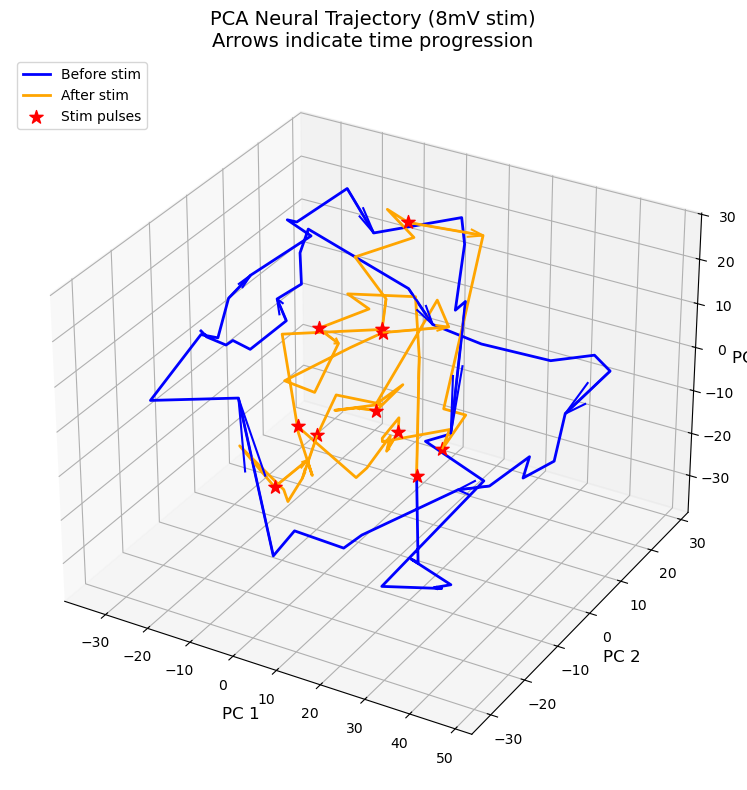

In [24]:
# --- 3D trajectory plot with PC3 on z-axis and arrows for time ---
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import matplotlib.colors as mcolors

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Time window: 50ms before and 50ms after stim start
stim_start_time = 50
window_start = 0
window_end = 100

# Find indices
start_idx = np.argmin(np.abs(time_axis - window_start))
end_idx = np.argmin(np.abs(time_axis - window_end))
stim_onset_idx = np.argmin(np.abs(time_axis - stim_start_time))

# Split into before and after stim
before_slice = slice(start_idx, stim_onset_idx + 1)
after_slice = slice(stim_onset_idx, end_idx + 1)

# Plot before stim (blue) with arrows
x_before = Z_pca[before_slice, 0]
y_before = Z_pca[before_slice, 1]
z_before = Z_pca[before_slice, 2]
ax.plot(x_before, y_before, z_before, color='blue', linewidth=2, label='Before stim')

# Add arrows for before stim (every 5 points)
for i in range(0, len(x_before)-1, 5):
    ax.quiver(x_before[i], y_before[i], z_before[i],
              x_before[i+1]-x_before[i], y_before[i+1]-y_before[i], z_before[i+1]-z_before[i],
              color='blue', arrow_length_ratio=0.5, linewidth=1.5)

# Plot after stim (orange) with arrows
x_after = Z_pca[after_slice, 0]
y_after = Z_pca[after_slice, 1]
z_after = Z_pca[after_slice, 2]
ax.plot(x_after, y_after, z_after, color='orange', linewidth=2, label='After stim')

# Add arrows for after stim (every 5 points)
for i in range(0, len(x_after)-1, 5):
    ax.quiver(x_after[i], y_after[i], z_after[i],
              x_after[i+1]-x_after[i], y_after[i+1]-y_after[i], z_after[i+1]-z_after[i],
              color='orange', arrow_length_ratio=0.2, linewidth=1.5)

# Mark every stim time point with a star
stim_times = np.arange(50, 100 + 1, 5)
for i, stim_t in enumerate(stim_times):
    stim_idx = np.argmin(np.abs(time_axis - stim_t))
    if i == 0:
        ax.scatter(Z_pca[stim_idx, 0], Z_pca[stim_idx, 1], Z_pca[stim_idx, 2],
                   color='red', s=100, marker='*', label='Stim pulses', zorder=10)
    else:
        ax.scatter(Z_pca[stim_idx, 0], Z_pca[stim_idx, 1], Z_pca[stim_idx, 2],
                   color='red', s=100, marker='*', zorder=10)

ax.set_xlabel('PC 1', fontsize=12)
ax.set_ylabel('PC 2', fontsize=12)
ax.set_zlabel('PC 3', fontsize=12)
ax.set_title('PCA Neural Trajectory (8mV stim)\nArrows indicate time progression', fontsize=14)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

## dPCA

In [19]:
# --- Apply dPCA ---
# For dPCA we need multiple "stimulus conditions". 
# We'll treat before-stim (0-50ms) and during-stim (50-100ms) as 2 conditions
# Each 50ms window = 50 time points

from dPCA import dPCA

# Run multiple trials for dPCA regularization
def run_trial(seed):
    b2.start_scope()
    np.random.seed(seed)
    
    n = 100
    ng = b2.NeuronGroup(
        n,
        '''
        dv/dt = (-(v - E_L) + Delta_T*exp((v-theta)/Delta_T) + Rm*(I_exc + I_bg)) / tau_m + sigma*sqrt(2/tau_m)*xi: volt
        I_exc : amp 
        ''',
        threshold="v > -10*mV", reset="v=E_L",
        namespace={"tau_m": 20*ms, "Rm": 500*b2.Mohm, "theta": -50*mV, "Delta_T": 2*mV, "E_L": -70*mV, "sigma": 5*mV, "I_bg": 60*pA},
        method='euler', dt=0.1*ms
    )
    ng.v = np.random.uniform(-70, -50, n) * mV
    ng.I_exc = 0 * pA
    
    W = 1 * mV
    S_ee = b2.Synapses(ng, model="w: 1", on_pre="v_post+=W*w/sqrt(n)")
    S_ee.connect(condition="abs(i-j)<=40 and i!=j")
    S_ee.w = np.exp(np.random.randn(len(S_ee))) * np.random.choice([-1, 1], len(S_ee))
    
    target_neurons = np.arange(10)
    pulse_times = np.arange(50, 150, 5) * ms
    stim_gen = b2.SpikeGeneratorGroup(10, np.tile(target_neurons, len(pulse_times)), np.repeat(pulse_times, len(target_neurons)))
    stim_syn = b2.Synapses(stim_gen, ng, on_pre='v += 8*mV')
    stim_syn.connect(j='i')
    
    state_mon = b2.StateMonitor(ng, 'v', record=True, dt=1*ms)
    net = b2.Network(ng, S_ee, stim_gen, stim_syn, state_mon)
    net.run(150 * ms)
    
    return state_mon.v[:] / mV

# Run 5 trials
print("Running trials for dPCA...")
n_trials = 5
trial_data = [run_trial(seed=i*10) for i in range(n_trials)]

# Create dPCA format: (n_trials, n_neurons, n_stim_conditions, n_time)
# Condition 0: no stim (0-50ms), Condition 1: stim (50-100ms)
T = 50  # time points per condition
N = 100  # neurons
S = 2   # conditions (before/after)

trialR_dpca = np.zeros((n_trials, N, S, T))
for trial_idx, data in enumerate(trial_data):
    trialR_dpca[trial_idx, :, 0, :] = data[:, 0:50]    # no stim condition
    trialR_dpca[trial_idx, :, 1, :] = data[:, 50:100]  # stim condition

# Trial-averaged data
R_dpca = np.mean(trialR_dpca, axis=0)
R_dpca_centered = R_dpca - np.mean(R_dpca.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA data shape: {R_dpca_centered.shape}")

# Fit dPCA
dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=2)
dpca.protect = ['t']
Z_dpca = dpca.fit_transform(R_dpca_centered, trialR_dpca)

print(f"dPCA components: {Z_dpca.keys()}")

WARNING    'i' is an internal variable of group 'synapses_2', but also exists in the run namespace with the value 10. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


Running trials for dPCA...


WARNING    'i' is an internal variable of group 'synapses_3', but also exists in the run namespace with the value 10. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


dPCA data shape: (100, 2, 50)
You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.2689264815224247
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA components: dict_k

Top 3 dPCA components by explained variance:
  1. Time component 1: 0.000000%
  2. Interaction component 1: 0.000000%
  3. Time component 2: 0.000000%


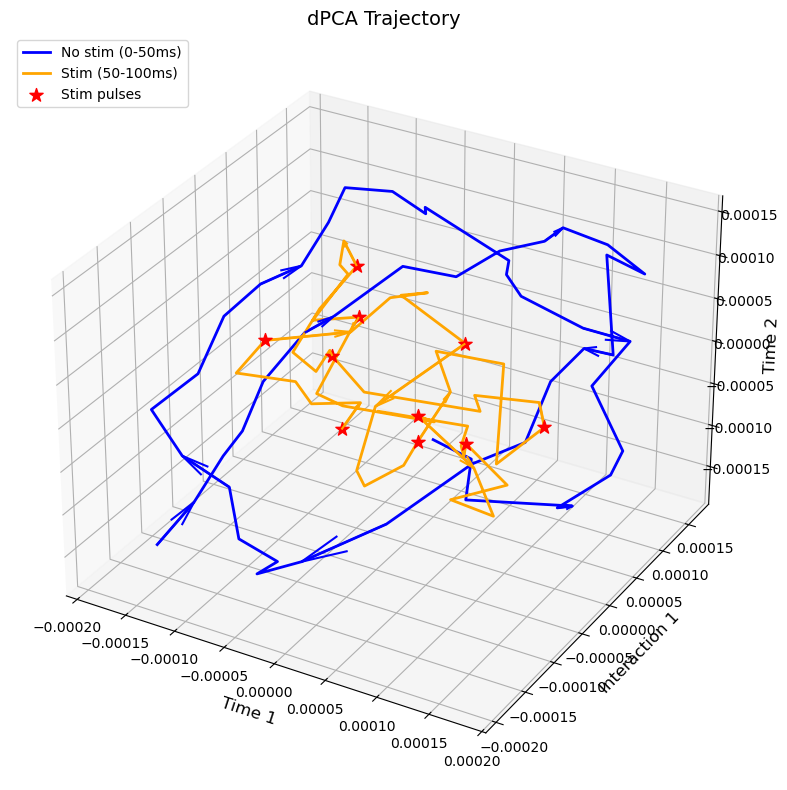

In [29]:
# --- Select top 3 components by explained variance across all marginalizations ---

# Collect all components with their explained variance
all_components = []
for key in Z_dpca.keys():
    if hasattr(dpca, 'explained_variance_ratio_') and key in dpca.explained_variance_ratio_:
        for comp_idx, var_ratio in enumerate(dpca.explained_variance_ratio_[key]):
            all_components.append({
                'key': key,
                'comp_idx': comp_idx,
                'var_ratio': var_ratio,
                'data': Z_dpca[key][comp_idx]
            })

# Sort by explained variance (descending)
all_components.sort(key=lambda x: x['var_ratio'], reverse=True)

# Get top 3 components
top3 = all_components[:3]
print("Top 3 dPCA components by explained variance:")
for i, comp in enumerate(top3):
    label = {'t': 'Time', 's': 'Stimulus', 'st': 'Interaction'}[comp['key']]
    print(f"  {i+1}. {label} component {comp['comp_idx']+1}: {comp['var_ratio']*100:.6f}%")

# --- Plot using top 3 components ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Colors for conditions
color_no_stim = 'blue'
color_stim = 'orange'

# Get data for top 3 components
x_no_stim = top3[0]['data'][0, :]  # condition 0
y_no_stim = top3[1]['data'][0, :]
z_no_stim = top3[2]['data'][0, :]

x_stim = top3[0]['data'][1, :]  # condition 1
y_stim = top3[1]['data'][1, :]
z_stim = top3[2]['data'][1, :]

# Plot no-stim condition
ax.plot(x_no_stim, y_no_stim, z_no_stim, color=color_no_stim, linewidth=2, label='No stim (0-50ms)')

# Add arrows for no-stim (every 5 points)
for i in range(0, len(x_no_stim)-1, 5):
    ax.quiver(x_no_stim[i], y_no_stim[i], z_no_stim[i],
              x_no_stim[i+1]-x_no_stim[i], y_no_stim[i+1]-y_no_stim[i], z_no_stim[i+1]-z_no_stim[i],
              color=color_no_stim, arrow_length_ratio=0.5, linewidth=1.5)

# Plot stim condition
ax.plot(x_stim, y_stim, z_stim, color=color_stim, linewidth=2, label='Stim (50-100ms)')

# Add arrows for stim (every 5 points)
for i in range(0, len(x_stim)-1, 5):
    ax.quiver(x_stim[i], y_stim[i], z_stim[i],
              x_stim[i+1]-x_stim[i], y_stim[i+1]-y_stim[i], z_stim[i+1]-z_stim[i],
              color=color_stim, arrow_length_ratio=0.2, linewidth=1.5)

# Mark stim pulses
stim_times_rel = np.arange(0, 50, 5)
for i, st in enumerate(stim_times_rel):
    if i == 0:
        ax.scatter(x_stim[st], y_stim[st], z_stim[st],
                   color='red', s=100, marker='*', label='Stim pulses', zorder=10)
    else:
        ax.scatter(x_stim[st], y_stim[st], z_stim[st],
                   color='red', s=100, marker='*', zorder=10)

# Labels based on top components
labels = []
for comp in top3:
    label = {'t': 'Time', 's': 'Stimulus', 'st': 'Interaction'}[comp['key']]
    labels.append(f"{label} {comp['comp_idx']+1}")

ax.set_xlabel(labels[0], fontsize=12)
ax.set_ylabel(labels[1], fontsize=12)
ax.set_zlabel(labels[2], fontsize=12)
ax.set_title('dPCA Trajectory', fontsize=14)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()